<a href="https://colab.research.google.com/github/mandosanti06/SpectrumX-hackathon/blob/main/groundTruthComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting Up

Before we start, let's set up our environment.

Start by adding all the provided test files to the home directory. Then run the code in the cell below to import some helpful libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas

trace = "easy" #change to easy, medium1, medium2, hard to try other files
testFile = "/content/" + trace + ".csv"
groundTruthFile = "/content/" + trace + "_groundtruth.csv"

# Reading a Spectrogam
The provided traces are saved as a csv file. We can read these csv files into a matrix so that we can work with them. Each value in the matrix is a power level at a given time and frequency.

Run the code below to visualize the given trace looks like.


[[-113.46892728 -110.27557817 -114.87836759 ... -105.36112387
  -108.3030379  -101.99514404]
 [-106.25164534 -107.85259406 -113.90036854 ... -108.09341685
  -107.84885928 -109.49551823]
 [-106.6068415  -103.09942574 -108.43231939 ... -108.08536529
  -113.48143459 -108.69773351]
 ...
 [-106.07020269 -109.59462044 -112.17012483 ... -112.54173795
  -107.70044658 -109.27285569]
 [-103.42968934 -112.07579415 -110.13691284 ... -109.18645093
  -112.08914946 -110.01095345]
 [-113.09648791 -107.24580092 -104.48245772 ... -110.36128414
  -110.82224931 -111.3625187 ]]


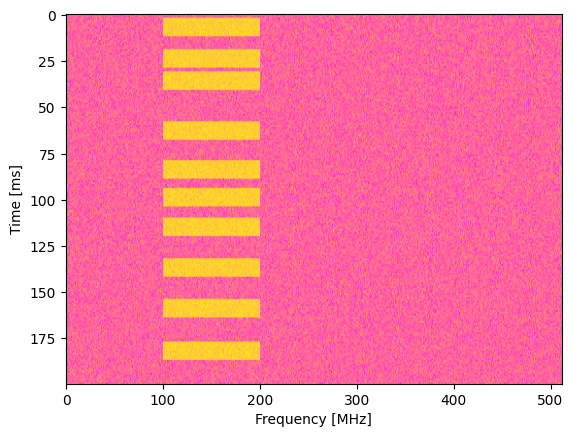

In [ ]:
#reading spectrogram from a csv.
spectrogram = pandas.read_csv(testFile, header=None)
spectrogram = spectrogram.to_numpy()
fft_size = 1024
sample_rate = 1e6
print(spectrogram)
plt.imshow(spectrogram, cmap=plt.cm.spring, aspect='auto')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [ms]")
plt.show()

# Transmission vs Noise: Thresholding

How can we tell which parts of the trace contain a transmission and which parts are noise?

For the "easy" file, it may seem simple. The brighter blocks are transmissions. We can try to guess that any power level above a certain value is part of the tranmission, and anything below that is noise.

In the file below, try adjusting the threshold. Time-Frequency cells that are above that threshold will be marked as 1 and those below will be marked as 0.

Try to find the best threshold to detect the given tranmission without too many errors.

[[0. 0. 0. ... 1. 1. 1.]
 [1. 1. 0. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 0. 1.]
 ...
 [1. 1. 0. ... 0. 1. 1.]
 [1. 0. 0. ... 1. 0. 0.]
 [0. 1. 1. ... 0. 0. 0.]]


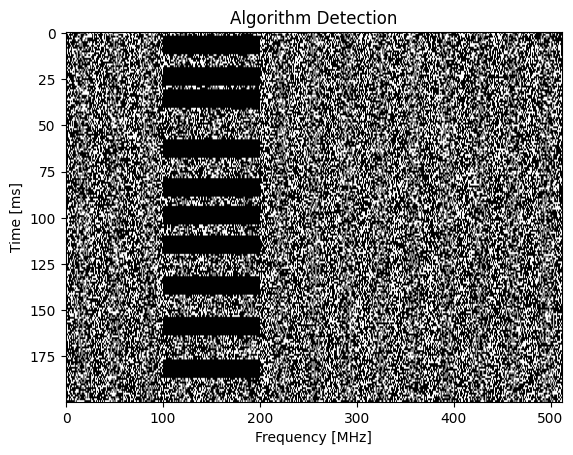

In [ ]:
#simple thresholding
rows = spectrogram.shape[0]
columns = spectrogram.shape[1]
detectionImage = np.zeros((rows,columns))
for i in range(rows):
     for j in range(columns):
       if spectrogram[i][j] < -110: #adjust threshold
         detectionImage[i][j]  = 0.0
       else:
         detectionImage[i][j]  = 1.0
print(detectionImage)
df = pandas.DataFrame(detectionImage)
df.to_csv("/content/detection.csv", header=False, index=False)
plt.imshow(detectionImage, cmap=plt.cm.binary, aspect='auto')
plt.title("Algorithm Detection")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [ms]")
plt.show()

# Similarity Measure

We can measure how accurate our detection is by using the [Jaccard Similarity](https://en.wikipedia.org/wiki/Jaccard_index#Similarity_of_asymmetric_binary_attributes).

Run the code below to determine the jaccard similarity for the detection that uses your given threshold. Try adjusting your threshold in the above cell, and then running the code again. Find the threshold that results in the best similarity value.

Jaccard Similarity: 0.15328254571651925


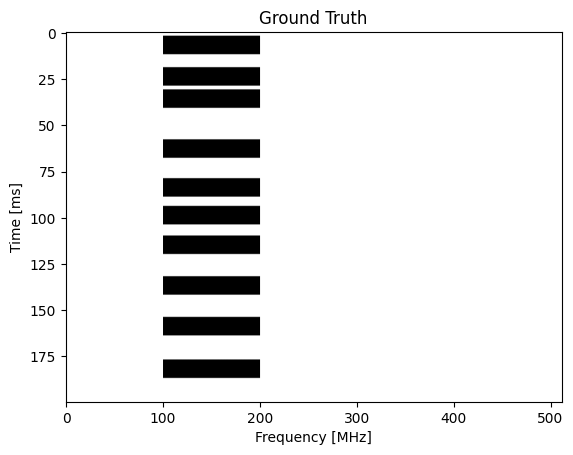

In [ ]:
#Similarity Test
detectionFile = "/content/detection.csv"

detection = pandas.read_csv(detectionFile, header=None)
groundTruth = pandas.read_csv(groundTruthFile, header=None)
rows = detection.shape[1]
columns = detection.shape[0]

truePositives = 0 #ground truth and algorithm both detect transmission
trueNegatives = 0 #ground truth and algorithm both do not detect transmission
falsePositives = 0 #ground truth says no transmission, algorithm says transmission
falseNegatives = 0 #ground truth says transmission, algorithm says no transmission

for row in range(rows):
  for column in range(columns):
    if groundTruth[row][column] == detection[row][column] == 1:
      truePositives +=1
    elif groundTruth[row][column] == detection[row][column] == 0:
      trueNegatives +=1
    elif detection[row][column] == 1:
      falsePositives +=1
    else:
      falseNegatives += 1

#print(truePositives, trueNegatives, falsePositives, falseNegatives)

jaccard = truePositives/(truePositives + falsePositives + falseNegatives)
print("Jaccard Similarity:", jaccard)


plt.imshow(groundTruth, cmap=plt.cm.binary, aspect='auto')
plt.title("Ground Truth")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Time [ms]")
plt.show()

# Best Thresholds for All Traces
Now that you have found the best threshold for the easy trace, find the best threshold for each of the other traces.
Write down the highest jaccard similarity and best threshold you found for each file.

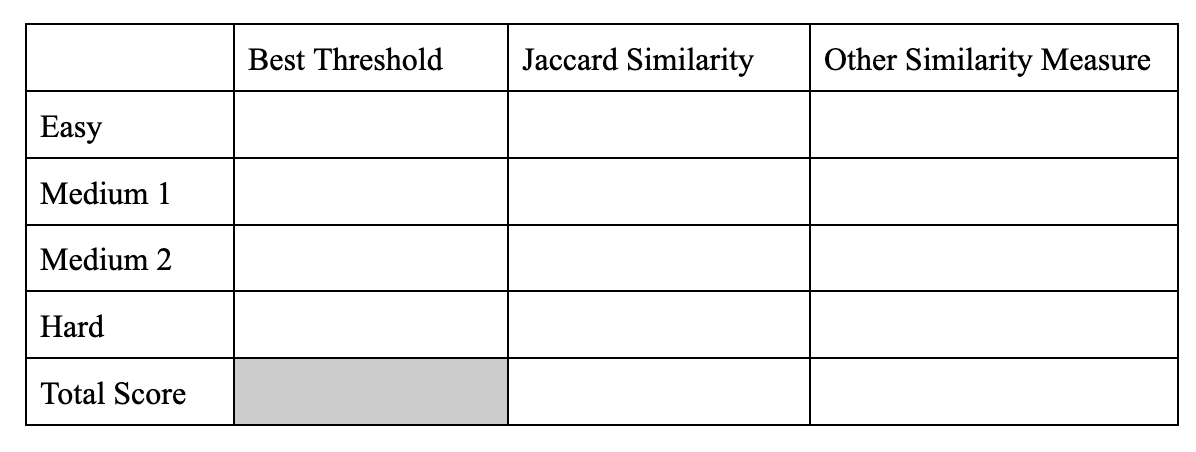